# Gruppen Abgabe

Die besten CNN-Modelle der jeweiligen Gruppenmitglieder werden geladen und einzeln bewertet.

- Dateiformat ist .keras
- TensorFlow / Keras Version: 2.14
- Alle Modelle erwarten Eingaben der Form `(28, 28, 1)` und sind auf normalisierten Daten (0 - 1) trainiert

Anschließend werden die Modelle mit verschiedenen Ensemble Verfahren zu neuen Modellen zusammengeführt.


In [120]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

print("tensorflow:", tf.__version__)
print("keras:", keras.__version__)

tensorflow: 2.14.0
keras: 2.14.0


## MNIST Testdaten laden und vorverarbeiten


In [121]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]

print(f"Training Datensätze: {x_train.shape}")

x_test = x_test.astype('float32') / 255.0
x_test = x_test[..., np.newaxis]

print(f"Test Datensätze : {x_test.shape}")

print(f"Wertebereich : [{x_test.min():.2f}, {x_test.max():.2f}]")
print(f"Klassen : {np.unique(y_test)}")

Training Datensätze: (60000, 28, 28, 1)
Test Datensätze : (10000, 28, 28, 1)
Wertebereich : [0.00, 1.00]
Klassen : [0 1 2 3 4 5 6 7 8 9]


## Modelle laden


In [122]:
main_path = "Besten Modelle"

all_models = {}

all_models["Vincent"] = keras.models.load_model(os.path.join(main_path, "CNN_Vincent.keras"))
all_models["Elma"] = keras.models.load_model(os.path.join(main_path, "CNN_Elma.keras"))
all_models["Katarina"] = keras.models.load_model(os.path.join(main_path, "CNN_Katarina.keras"))
all_models["Ilker"] = keras.models.load_model(os.path.join(main_path, "CNN_Ilker.keras"))
all_models["Jana"] = keras.models.load_model(os.path.join(main_path, "CNN_Jana.keras"))

print(f"\nGesamtanzahl geladener Modelle: {len(all_models)}")


Gesamtanzahl geladener Modelle: 5


# Einzelbewertung


In [123]:
single_results = {}

## Ilker


In [124]:
model = all_models["Ilker"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Ilker"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9947
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (No

## Jana


In [125]:
model = all_models["Jana"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Jana"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9955
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        288       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9216      
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 32)        128       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)   (No

## Elma


In [126]:
model = all_models["Elma"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Elma"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9939
Model: "cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 32)        9248      
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 32)        0         
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 conv_4 (Conv2D)             (Non

## Katarina


In [127]:
model = all_models["Katarina"]
try:
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
except ValueError:
    preds = model.predict(x_test, verbose=0)
    if preds.ndim == 2 and preds.shape[1] > 1:
        acc = float(np.mean(np.argmax(preds, axis=1) == y_test))
    else:
        acc = float(np.mean((preds.ravel() > 0.5).astype(int) == y_test))

single_results["Katarina"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9927
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                                                 
 dropout_1 (Dropout)         (

## Vincent


In [128]:
model = all_models["Vincent"]
loss, acc = model.evaluate(x_test, y_test, verbose=0)

single_results["Vincent"] = acc

print(f"Testgenauigkeit: {acc:.4f}")
model.summary()

Testgenauigkeit: 0.9947
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 64)        640       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 64)        256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 64)        36928     
                                                                 
 batch_normalization_1 (Bat  (None, 28, 28, 64)        256       
 chNormalization)             

## Einzelbewertung Zusammenfassung



Durchschnittliche Accuracy : 0.9943


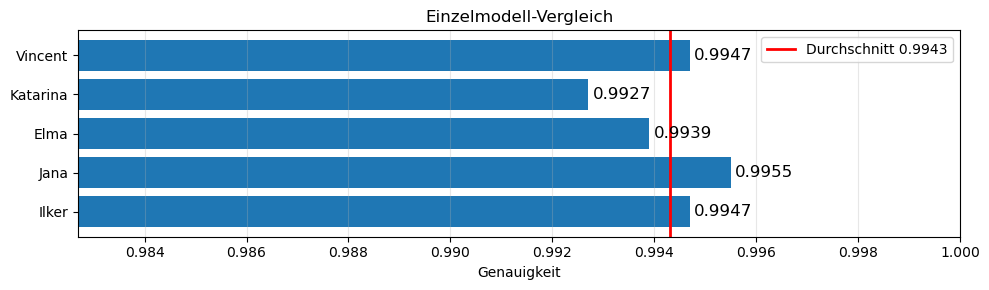

In [129]:
avg_acc = np.mean(list(single_results.values()))
print(f"\nDurchschnittliche Accuracy : {avg_acc:.4f}")

results_max = np.max(list(single_results.values()))

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.barh(list(single_results.keys()), list(single_results.values()))

x_min = min(single_results.values()) - 0.01
x_max = 1.0

ax.set_xlim(x_min, x_max)
ax.axvline(avg_acc, color="red", linewidth=2, label=f"Durchschnitt {avg_acc:.4f}")

for bar, val in zip(bars, single_results.values()):
    ax.text(bar.get_width() + (x_max - x_min) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left", fontsize=12)

ax.set_xlabel("Genauigkeit")
ax.set_title("Einzelmodell-Vergleich")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Ensemble (Gruppenbewertung)


## Majority Voting Ensemble

Jedes Modell gibt eine Klasse aus. Die Klasse mit den meisten Stimmen gewinnt.
Bei Stimmengleichheit wird die Klasse mit der höchsten durchschnittlichen Wahrscheinlichkeit gewählt.


In [130]:
all_probs = [model.predict(x_test, verbose=0) for model in all_models.values()]

predictions_stack = np.array(all_probs)       
hard_preds        = np.argmax(predictions_stack, axis=2) 
votes             = hard_preds.T              

avg_probs_stack = predictions_stack.mean(axis=0)

majority_preds = np.array([
    np.bincount(row, minlength=10).argmax()
    if np.bincount(row, minlength=10).max() > 1
    else np.argmax(avg_probs_stack[i])
    for i, row in enumerate(votes)
])

acc_majority = float(np.mean(majority_preds == y_test))
print(f"Majority Voting Ergebnis: {acc_majority:.4f}")

Majority Voting Ergebnis: 0.9957


## Soft Voting Ensemble

Alle Modelle liefern Wahrscheinlichkeitsvektoren. Diese werden gemittelt und die Klasse mit der höchsten durchschnittlichen Wahrscheinlichkeit gewählt.


In [131]:
soft_avg_probs = predictions_stack.mean(axis=0)   # (10000, 10)
soft_preds     = np.argmax(soft_avg_probs, axis=1)

acc_soft = float(np.mean(soft_preds == y_test))
print(f"Soft Voting Ergebnis     : {acc_soft:.4f}")

Soft Voting Ergebnis     : 0.9956


## Weighted Average Voting Ensemble

Jedes Modell wird nach seiner Einzelmodell-Genauigkeit gewichtet. Bessere Modelle haben entsprechend mehr Einfluss auf die finale Vorhersage.


In [132]:
model_names = list(all_models.keys())
model_accs = np.array([single_results.get(name, avg_acc) for name in model_names])

model_accs_sum = np.sum(model_accs)
if model_accs_sum == 0:
    weights = np.ones_like(model_accs) / len(model_accs)
else:
    weights = model_accs / model_accs_sum
weights_broadcast = weights.reshape((-1, 1, 1))
weighted_probs = np.sum(predictions_stack * weights_broadcast, axis=0)
weighted_preds = np.argmax(weighted_probs, axis=1)

print(f"\nGewichte der Modelle:")
for name, w in zip(model_names, weights):
    print(f"  {name:50s}  w={w:.4f}")

acc_weighted = float(np.mean(weighted_preds == y_test))
print(f"Weighted Voting Ergebnis: {acc_weighted:.4f}")




Gewichte der Modelle:
  Vincent                                             w=0.2001
  Elma                                                w=0.1999
  Katarina                                            w=0.1997
  Ilker                                               w=0.2001
  Jana                                                w=0.2002
Weighted Voting Ergebnis: 0.9956


## Meta-Learner Stacking Ensemble

Die Vorhersagen der 5 Basismodelle werden als Features für einen Meta-Learner (Logistic Regression) verwendet.
Der Meta-Learner lernt, wie er die Modellausgaben optimal kombiniert.

Der Meta-Learner wird auf den Trainingsdaten trainiert und auf den Testdaten evaluiert, um Data Leakage zu vermeiden.


In [133]:
train_probs = [model.predict(x_train, verbose=0) for model in all_models.values()]
train_meta_features = np.hstack(train_probs)

test_meta_features = np.hstack([p for p in all_probs])

print(f"Meta-Feature Shape Train : {train_meta_features.shape}")
print(f"Meta-Feature Shape Test  : {test_meta_features.shape}")

meta_learner = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

meta_learner.fit(train_meta_features, y_train)

meta_preds = meta_learner.predict(test_meta_features)
acc_stacking = float(np.mean(meta_preds == y_test))

print(f"\nMeta-Learner Stacking Ergebnis: {acc_stacking:.4f}")


Meta-Feature Shape Train : (60000, 50)
Meta-Feature Shape Test  : (10000, 50)

Meta-Learner Stacking Ergebnis: 0.9954


## Ensemble Zusammenfassung


In [134]:
def plot_summary(
    results_1,
    results_2,
    title,
    results_1_name,
    results_2_name
):
    single_plot_results = {name: float(acc) for name, acc in results_1.items()}
    ensemble_plot_results = {name: float(acc) for name, acc in results_2.items()}

    comparison_results = {**single_plot_results, **ensemble_plot_results}
    labels = list(comparison_results.keys())
    values = np.array(list(comparison_results.values()))
    colors = ["#8f8f8f"] * len(single_plot_results) + ["#5b9bd5"] * len(ensemble_plot_results)

    avg_single_models = float(np.mean(list(single_plot_results.values())))
    avg_ensembles = float(np.mean(list(ensemble_plot_results.values())))

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars = ax.barh(labels, values, color=colors)

    x_min = max(0.0, values.min() - 0.003)
    x_max = min(1.0, values.max() + 0.003)
    ax.set_xlim(x_min, x_max)
    ax.invert_yaxis()

    for bar, value in zip(bars, values):
        ax.text(
            value + (x_max - x_min) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            ha="left",
            fontsize=11,
        )

    ax.axvline(
        avg_single_models,
        color="#555555",
        linestyle="--",
        linewidth=2,
        label=f"Durchschnitt Einzelmodelle: {avg_single_models:.4f}",
    )
    ax.axvline(
        avg_ensembles,
        color="#2f6db3",
        linestyle="--",
        linewidth=2,
        label=f"Durchschnitt Ensembles: {avg_ensembles:.4f}",
    )

    fig.subplots_adjust(bottom=0.18)
    fig.text(
        0.5,
        0.04,
        f"{results_1_name}: {avg_single_models:.4f}    |    {results_2_name}: {avg_ensembles:.4f}",
        ha="center",
        va="center",
        fontsize=11,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none", "pad": 4},
    )


    ax.set_xlabel("Genauigkeit")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return fig, ax

In [135]:
print(f"  Anzahl Einzelmodelle            : {len(all_models)}")
print("---------------------------------------")
print(f"  Schlechtestes Einzelmodell: {np.min(list(single_results.values())):.4f}")
print(f"  Bestes Einzelmodell       : {np.max(list(single_results.values())):.4f}")
print(f"  Durchschnitt Einzelmodelle: {avg_acc:.4f}")
print("---------------------------------------")
print(f"  Majority Voting Ensemble  : {acc_majority:.4f}")
print(f"  Soft Voting Ensemble      : {acc_soft:.4f}")
print(f"  Weighted Voting Ensemble  : {acc_weighted:.4f}")
print(f"  Meta-Learner     : {acc_stacking:.4f}")

  Anzahl Einzelmodelle            : 5
---------------------------------------
  Schlechtestes Einzelmodell: 0.9927
  Bestes Einzelmodell       : 0.9955
  Durchschnitt Einzelmodelle: 0.9943
---------------------------------------
  Majority Voting Ensemble  : 0.9957
  Soft Voting Ensemble      : 0.9956
  Weighted Voting Ensemble  : 0.9956
  Meta-Learner     : 0.9954


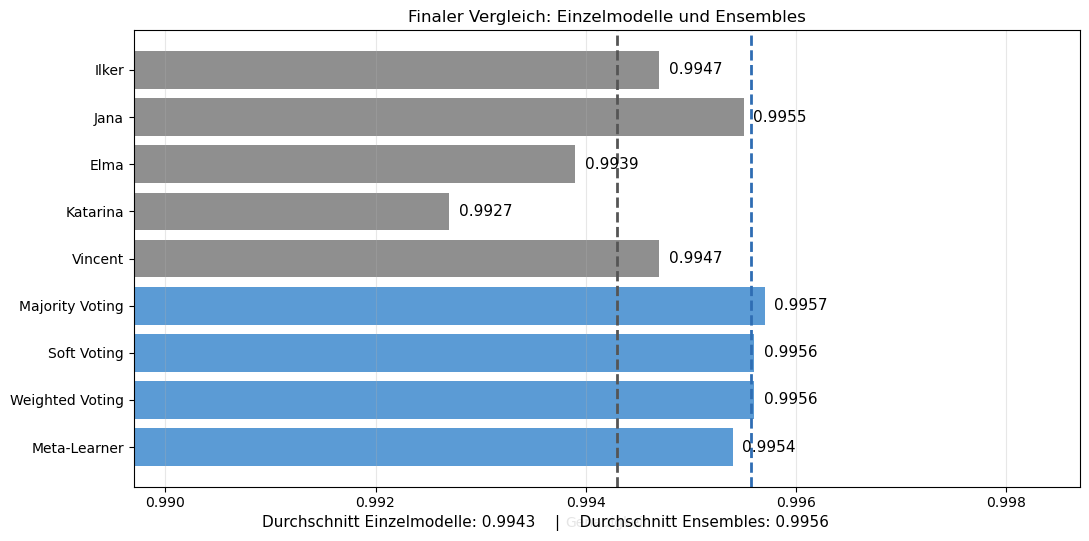

(<Figure size 1100x550 with 1 Axes>,
 <Axes: title={'center': 'Finaler Vergleich: Einzelmodelle und Ensembles'}, xlabel='Genauigkeit'>)

In [136]:
single_plot_results = {name: float(acc) for name, acc in single_results.items()}
ensemble_plot_results = {
    "Majority Voting": float(acc_majority),
    "Soft Voting": float(acc_soft),
    "Weighted Voting": float(acc_weighted),
    "Meta-Learner": float(acc_stacking),
}

plot_summary(single_plot_results, ensemble_plot_results,"Finaler Vergleich: Einzelmodelle und Ensembles", "Durchschnitt Einzelmodelle", "Durchschnitt Ensembles")

## Vergleich mit Modellen aus der Vorlesung


In [137]:
lecture_results = {}

### Perceptron aus Kapitel 3


In [138]:
data = load_digits()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)

def evaluate_sklearn(name, clf, x_tr, y_tr, x_te, y_te):
    clf.fit(x_tr, y_tr)

    print(f"{name} Testgenauigkeit: {clf.score(x_te, y_te):.4f}")

    lecture_results[f"Vorlesung: {name}"] = clf.score(x_te, y_te)


evaluate_sklearn(
    "Perceptron",
    Perceptron(tol=None, eta0=0.001, max_iter=10000, random_state=23),
    x_train,
    y_train,
    x_test,
    y_test,
)

Perceptron Testgenauigkeit: 0.9389


### Modelle und Ensemble aus Kapitel 7


In [139]:
evaluate_sklearn(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=8),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "kNN",
    KNeighborsClassifier(n_neighbors=27),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "SVM", SVC(probability=True), x_train, y_train, x_test, y_test
)

evaluate_sklearn(
    "Logistic Regression",
    LogisticRegression(),
    x_train,
    y_train,
    x_test,
    y_test,
)

evaluate_sklearn(
    "Random Forest",
    RandomForestClassifier(n_estimators=1000),
    x_train,
    y_train,
    x_test,
    y_test,
)

clf1 = RandomForestClassifier(n_estimators=1000)
clf2 = KNeighborsClassifier(n_neighbors=27)
clf3 = SVC(probability=True)
clf4 = LogisticRegression()
estimators = [("tree", clf1), ("kNN", clf2), ("SVM", clf3), ("LR", clf4)]

evaluate_sklearn(
    "Soft Voting Ensemble",
    VotingClassifier(estimators=estimators, voting="soft"),
    x_train,
    y_train,
    x_test,
    y_test,
)

Decision Tree Testgenauigkeit: 0.8361
kNN Testgenauigkeit: 0.9306
SVM Testgenauigkeit: 0.9861
Logistic Regression Testgenauigkeit: 0.9667
Random Forest Testgenauigkeit: 0.9750
Soft Voting Ensemble Testgenauigkeit: 0.9806


### CNN aus Kapitel 8


In [140]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

def create_simple_dropout_model():
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    x = keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        name="conv_1"
        )(inputs)

    x = keras.layers.MaxPooling2D(
        pool_size=(3, 3),
        name="maxpool_1"
        )(x)

    x = keras.layers.Flatten(name="flatten")(x)

    x = keras.layers.Dropout(
        rate=0.5,
        name="dropout"
        )(x)

    x = keras.layers.Dense(
        units=64,
        activation="relu",
        name="dense_1"
        )(x)

    outputs = keras.layers.Dense(
        units=10,
        activation="softmax",
        name="output"
        )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="simple_cnn_dropout"
        )

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        )

    return model


model_drop_full = create_simple_dropout_model()

model_drop_full.fit(
    x_train, y_train, batch_size=64, epochs=10, validation_split=0.2
)
test_loss, test_acc = model_drop_full.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
lecture_results["Vorlesung: CNN"] = test_acc

Epoch 1/10
750/750 [==============================] - 5s 6ms/step - loss: 0.3269 - accuracy: 0.9028 - val_loss: 0.1052 - val_accuracy: 0.9705
Epoch 2/10
750/750 [==============================] - 4s 6ms/step - loss: 0.1346 - accuracy: 0.9588 - val_loss: 0.0830 - val_accuracy: 0.9760
Epoch 3/10
750/750 [==============================] - 5s 6ms/step - loss: 0.1020 - accuracy: 0.9684 - val_loss: 0.0638 - val_accuracy: 0.9817
Epoch 4/10
750/750 [==============================] - 5s 6ms/step - loss: 0.0888 - accuracy: 0.9728 - val_loss: 0.0555 - val_accuracy: 0.9835
Epoch 5/10
750/750 [==============================] - 5s 7ms/step - loss: 0.0751 - accuracy: 0.9759 - val_loss: 0.0537 - val_accuracy: 0.9846
Epoch 6/10
750/750 [==============================] - 5s 7ms/step - loss: 0.0675 - accuracy: 0.9779 - val_loss: 0.0482 - val_accuracy: 0.9845
Epoch 7/10
750/750 [==============================] - 3s 4ms/step - loss: 0.0600 - accuracy: 0.9805 - val_loss: 0.0457 - val_accuracy: 0.9870
Epoch 

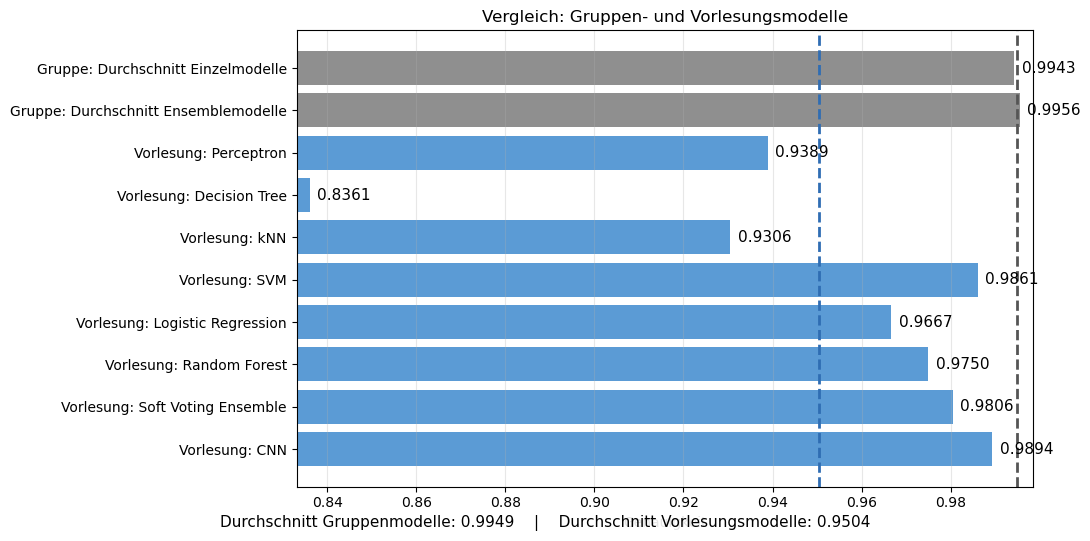

(<Figure size 1100x550 with 1 Axes>,
 <Axes: title={'center': 'Vergleich: Gruppen- und Vorlesungsmodelle'}, xlabel='Genauigkeit'>)

In [141]:
avg_single_plot_results = float(np.mean(list(single_plot_results.values())))
avg_ensemble_plot_results = float(np.mean(list(ensemble_plot_results.values())))

group_ensemble_results = {
    "Gruppe: Durchschnitt Einzelmodelle": avg_single_plot_results,
    "Gruppe: Durchschnitt Ensemblemodelle": avg_ensemble_plot_results
}

plot_summary(group_ensemble_results, lecture_results, "Vergleich: Gruppen- und Vorlesungsmodelle", "Durchschnitt Gruppenmodelle", "Durchschnitt Vorlesungsmodelle")